In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.io import imread
from tqdm.notebook import tqdm



In [2]:
# Base path to the competition data
PATH = "../input/alaska2-image-steganalysis"
# Use the sample submission as the prediction template
sub = pd.read_csv(os.path.join(PATH, "sample_submission.csv"))
# Initialise all predictions to 0 (no hidden data)
sub["Label"] = 0.0




In [3]:
class JPEGImageCompressionRateDeterminer:
    """Estimate a simple compression‑rate proxy for a JPEG image."""

    def __call__(self, image_path):
        # Load image; handle both colour (H,W,3) and grayscale (H,W)
        image = imread(image_path)
        if image.ndim == 2:  # grayscale
            h, w = image.shape
        else:  # colour
            h, w = image.shape[:2]
        n_bits = w * h * 3  # assume 3 bits per pixel as proxy
        image_size = os.stat(image_path).st_size
        return (n_bits - image_size) / n_bits




In [4]:
compression_rate_determiner = JPEGImageCompressionRateDeterminer()
compressions = {}

test_dir = os.path.join(PATH, "Test")
for impath in tqdm(sub["Id"].values, desc="Processing test images"):
    img_path = os.path.join(test_dir, impath)
    # Guard against missing files
    if not os.path.exists(img_path):
        continue
    c = compression_rate_determiner(img_path)
    compressions[impath] = c
    # Heuristic: very high compression rate → likely stego
    if c > 0.95:
        sub.loc[sub["Id"] == impath, "Label"] = 1.0



Processing test images:   0%|          | 0/5000 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


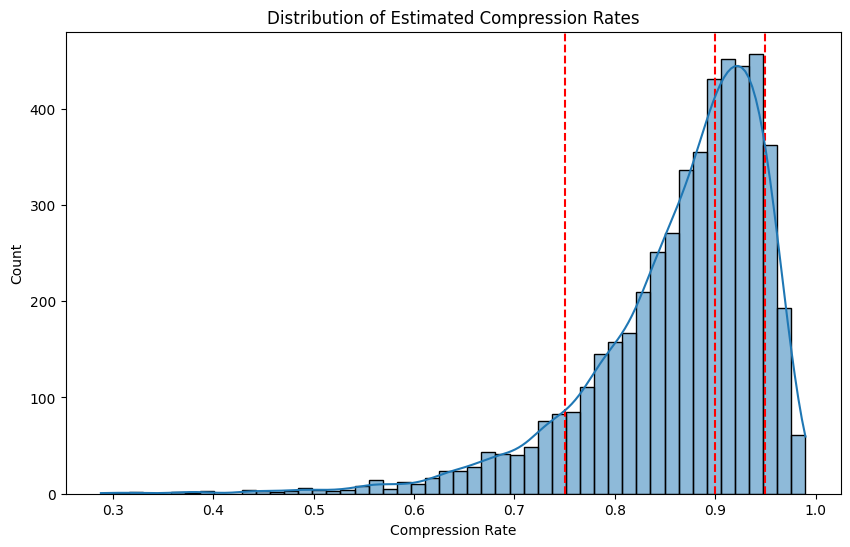

In [5]:
plt.figure(figsize=(10, 6))
plt.axvline(0.75, color="red", linestyle="--")
plt.axvline(0.90, color="red", linestyle="--")
plt.axvline(0.95, color="red", linestyle="--")
sns.histplot(list(compressions.values()), kde=True, bins=50)
plt.title("Distribution of Estimated Compression Rates")
plt.xlabel("Compression Rate")
plt.show()



/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


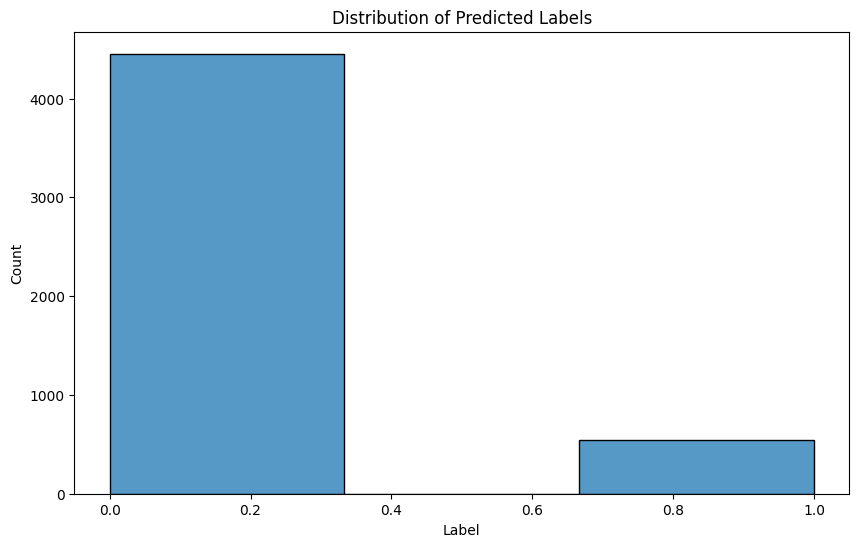

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(sub["Label"], bins=3, kde=False)
plt.title("Distribution of Predicted Labels")
plt.xlabel("Label")
plt.show()



In [7]:
# Save the submission file required by Kaggle
sub.to_csv("submission.csv", index=False)



In [8]:
# Quick sanity check
sub.head()

,Id,Label
0,0001.jpg,0.0
1,0002.jpg,0.0
2,0003.jpg,0.0
3,0004.jpg,0.0
4,0005.jpg,0.0
